# Explore here

In [107]:
# Your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

url = 'https://raw.githubusercontent.com/4GeeksAcademy/regularized-linear-regression-project-tutorial/main/demographic_health_data.csv'

# Cargo los datos
df = pd.read_csv(url)

print(df.head())

   fips  TOT_POP    0-9  0-9 y/o % of total pop  19-Oct  \
0  1001    55601   6787               12.206615    7637   
1  1003   218022  24757               11.355276   26913   
2  1005    24881   2732               10.980266    2960   
3  1007    22400   2456               10.964286    2596   
4  1009    57840   7095               12.266598    7570   

   10-19 y/o % of total pop  20-29  20-29 y/o % of total pop  30-39  \
0                 13.735364   6878                 12.370281   7089   
1                 12.344167  23579                 10.814964  25213   
2                 11.896628   3268                 13.134520   3201   
3                 11.589286   3029                 13.522321   3113   
4                 13.087828   6742                 11.656293   6884   

   30-39 y/o % of total pop  ...  COPD_number  diabetes_prevalence  \
0                 12.749771  ...         3644                 12.9   
1                 11.564429  ...        14692                 12.0   
2       

Valores faltantes por columna:
fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64
Columnas disponibles en el DataFrame:
['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct', '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop', '30-39', '30-39 y/o % of total pop', '40-49', '40-49 y/o % of total pop', '50-59', '50-59 y/o % of total pop', '60-69', '60-69 y/o % of total pop', '70-79', '70-79 y/o % of total pop', '80+', '80+ y/o % of total pop', 'White-alone pop', '% White-alone', 'Black-alone pop', '% Black-alone', 'Native American/American Indian-alone pop', '% NA/AI-alone', 'Asian-alone pop', '% Asian-alone', 'Hawaiian/Pacific Islander-alone pop', '% Hawaiian/PI-alone', 'Two or more races 

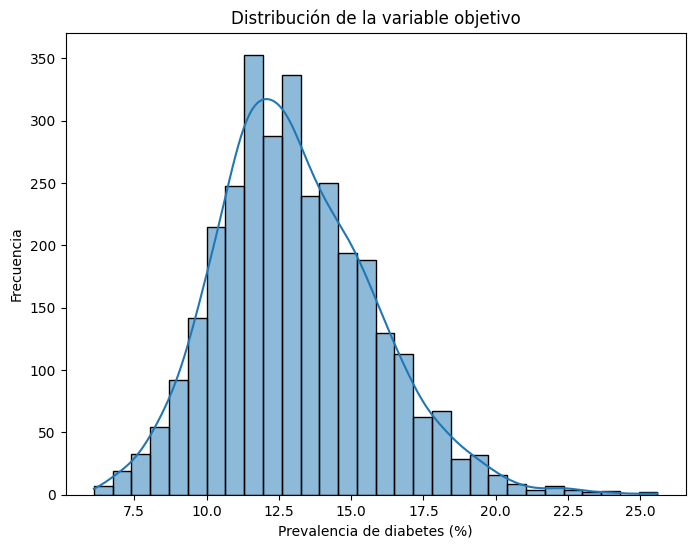


Número de columnas numéricas: 106


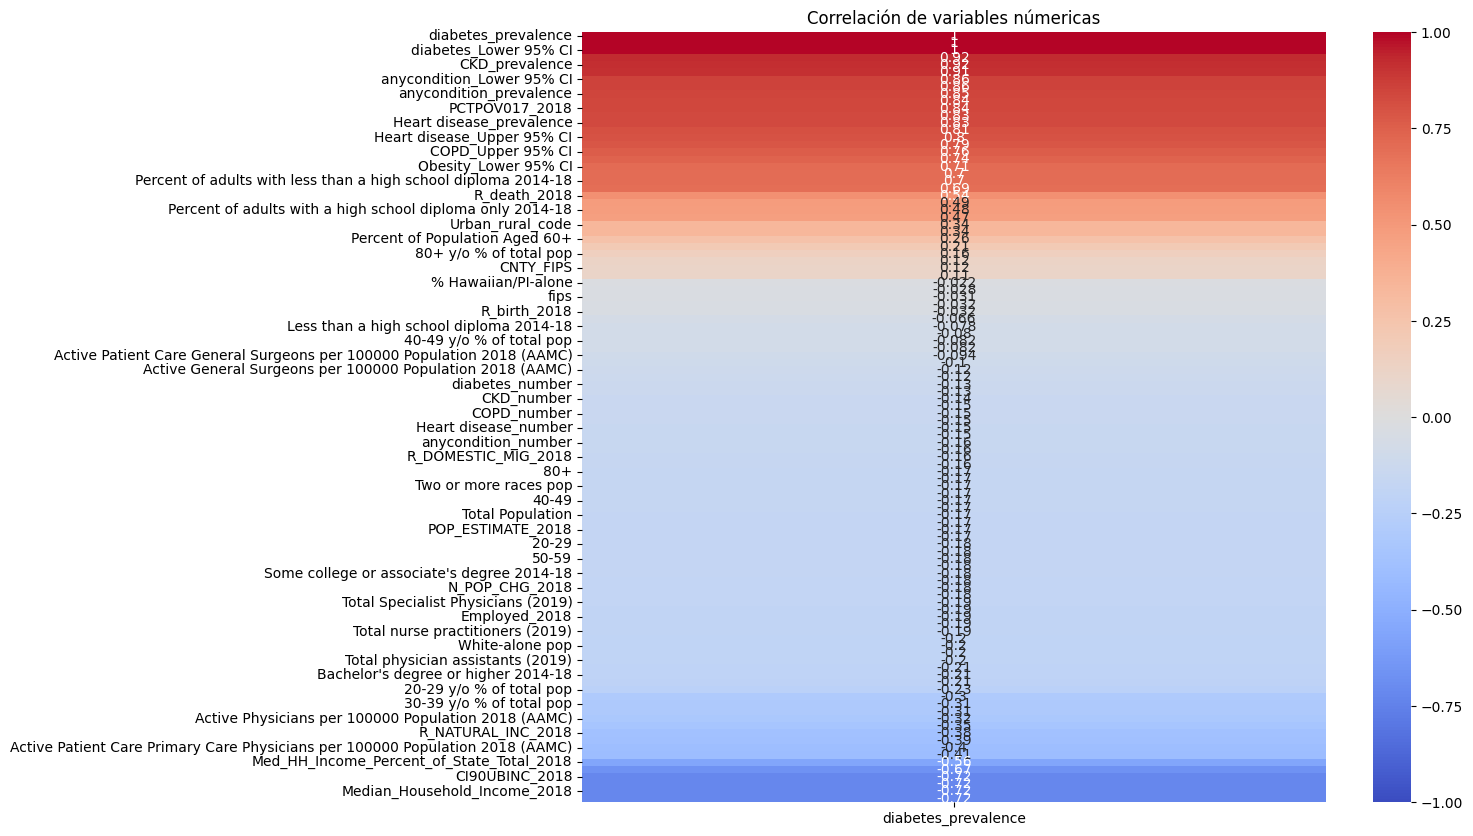


Columnas categóricas: Index(['COUNTY_NAME', 'STATE_NAME'], dtype='object')


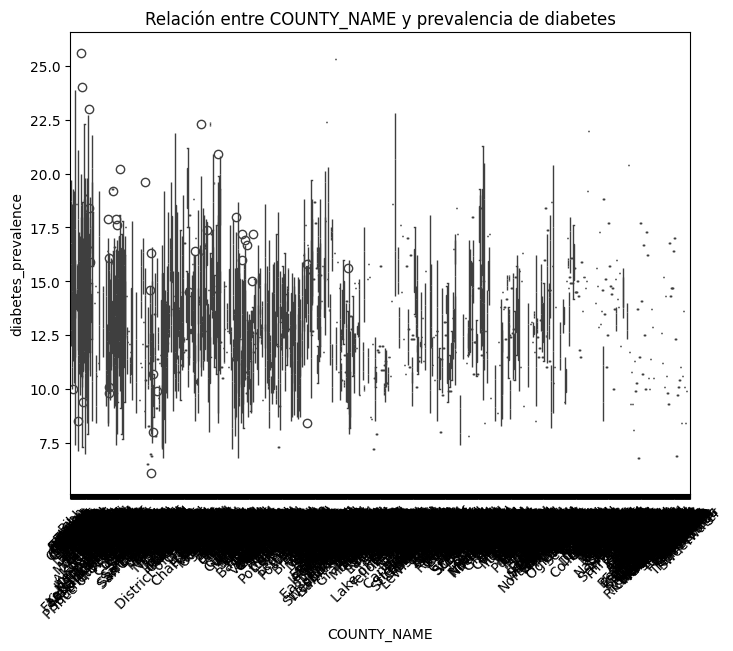

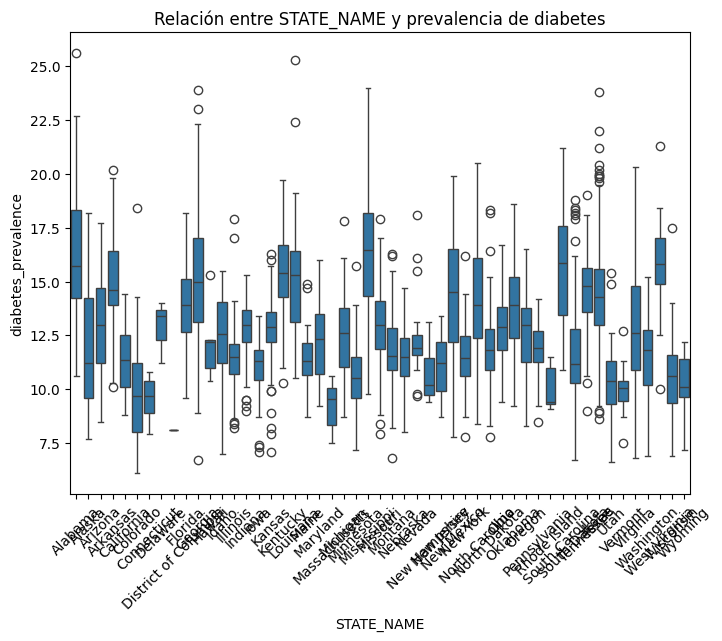

In [108]:
# Verificar valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum().sort_values(ascending=False))
print("Columnas disponibles en el DataFrame:")
print(df.columns.tolist())
# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())

# Distribuimos la variable objetivo (diabetes_prevalence)
plt.figure(figsize=(8, 6))
sns.histplot(df['diabetes_prevalence'], bins=30, kde=True)
plt.title('Distribución de la variable objetivo')
plt.xlabel('Prevalencia de diabetes (%)')
plt.ylabel('Frecuencia')
plt.show()

# Seleccionadas las variables numéricas para análisis de correlación
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("\nNúmero de columnas numéricas:", len(numeric_cols))

# Matriz de correlación con la variable objetivo
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix[['diabetes_prevalence']].sort_values(by='diabetes_prevalence', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de variables númericas')
plt.show()

# Seleccionar variables categóricas
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nColumnas categóricas:", categorical_cols)

# Relación entre variables categóricas y diabetes_prevalence
for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=col, y='diabetes_prevalence', data=df)
    plt.title(f'Relación entre {col} y prevalencia de diabetes')
    plt.xticks(rotation=45)
    plt.show()

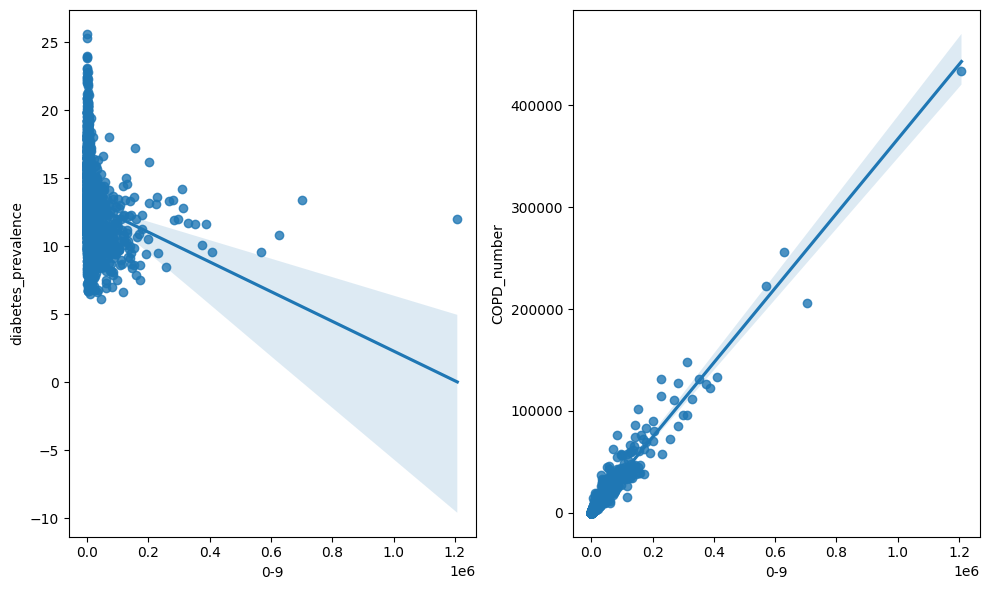

In [109]:
fig, axis = plt.subplots(figsize=(10, 6), ncols=2)
sns.regplot(ax=axis[0], data=df, x="0-9", y="diabetes_prevalence")
sns.regplot(ax=axis[1], data=df, x="0-9", y="COPD_number")
plt.tight_layout()
plt.show()



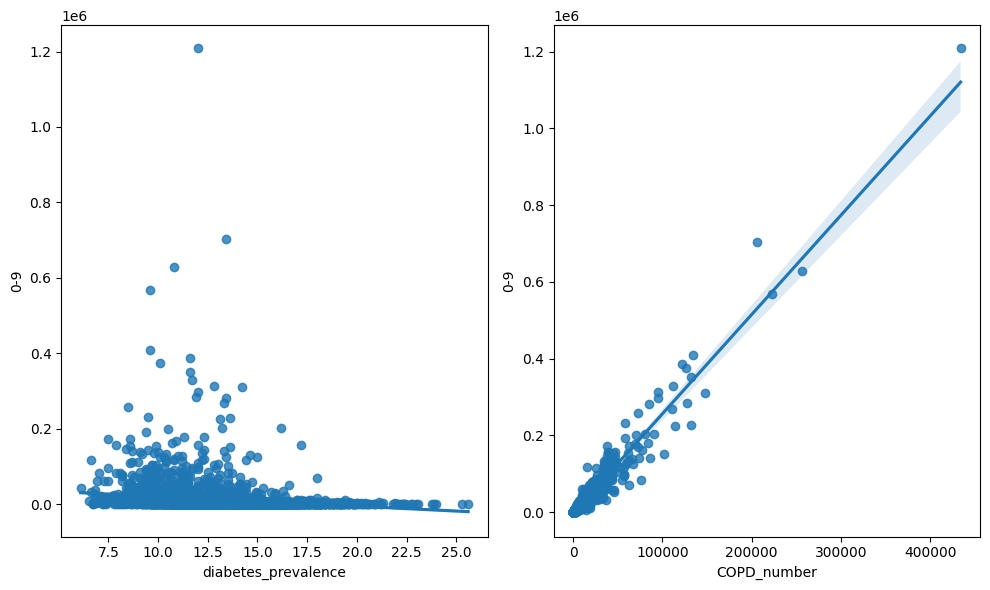

In [110]:
fig, axis = plt.subplots(figsize=(10, 6), ncols=2)
sns.regplot(ax=axis[0], data=df, x="diabetes_prevalence", y="0-9")
sns.regplot(ax=axis[1], data=df, x="COPD_number", y="0-9")
plt.tight_layout()
plt.show()

In [111]:
tot_pop_est = df["TOT_POP"].describe()
print(tot_pop_est)
iqr = tot_pop_est["75%"] - tot_pop_est["25%"]
upper_limit = tot_pop_est["75%"] + 1.5 * iqr
lower_limit = tot_pop_est["25%"] - 1.5 * iqr
print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(iqr, 2)}")
df = df[df["TOT_POP"] > 0]
tot_pop_val = df[df["TOT_POP"] > 0].shape[0]
print("Valores mayores de 0: ", tot_pop_val)

count    3.140000e+03
mean     1.041894e+05
std      3.335834e+05
min      8.800000e+01
25%      1.096325e+04
50%      2.580050e+04
75%      6.791300e+04
max      1.010552e+07
Name: TOT_POP, dtype: float64
Los límites superior e inferior para la búsqueda de outliers son 153337.62 y -74461.38, con un rango intercuartílico de 56949.75
Valores mayores de 0:  3140


In [112]:
# 0-9
zero_nine_est = df["0-9"].describe()
print(zero_nine_est)
iqr = zero_nine_est["75%"] - zero_nine_est["25%"]
upper_limit = zero_nine_est["75%"] + 1.5 * iqr
lower_limit = zero_nine_est["25%"] - 1.5 * iqr
print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(iqr, 2)}")
df = df[df["0-9"] >= 0]
zero_nine_val = df[df["0-9"] >= 0].shape[0]
print("Valores mayores o iguales a 0: ", zero_nine_val)

count    3.140000e+03
mean     1.274030e+04
std      4.180730e+04
min      0.000000e+00
25%      1.280500e+03
50%      3.057000e+03
75%      8.097000e+03
max      1.208253e+06
Name: 0-9, dtype: float64
Los límites superior e inferior para la búsqueda de outliers son 18321.75 y -8944.25, con un rango intercuartílico de 6816.5
Valores mayores o iguales a 0:  3140


In [113]:

# diabetes_prevalence
diabetes_est = df["diabetes_prevalence"].describe()
print(diabetes_est)
iqr = diabetes_est["75%"] - diabetes_est["25%"]
upper_limit = diabetes_est["75%"] + 1.5 * iqr
lower_limit = diabetes_est["25%"] - 1.5 * iqr
print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(iqr, 2)}")
df = df[df["diabetes_prevalence"] > 0]
diabetes_val = df[df["diabetes_prevalence"] > 0].shape[0]
print("Valores mayores de 0: ", diabetes_val)


count    3140.000000
mean       13.073503
std         2.724351
min         6.100000
25%        11.200000
50%        12.800000
75%        14.800000
max        25.600000
Name: diabetes_prevalence, dtype: float64
Los límites superior e inferior para la búsqueda de outliers son 20.2 y 5.8, con un rango intercuartílico de 3.6
Valores mayores de 0:  3140


In [114]:
# COPD_number
copd_est = df["COPD_number"].describe()
print(copd_est)
iqr = copd_est["75%"] - copd_est["25%"]
upper_limit = copd_est["75%"] + 1.5 * iqr
lower_limit = copd_est["25%"] - 1.5 * iqr
print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(iqr, 2)}")
df = df[df["COPD_number"] >= 0]
copd_val = df[df["COPD_number"] >= 0].shape[0]
print("Valores mayores o iguales a 0: ", copd_val)

count      3140.000000
mean       5827.242357
std       15720.551934
min           7.000000
25%         815.000000
50%        1963.500000
75%        4727.000000
max      434075.000000
Name: COPD_number, dtype: float64
Los límites superior e inferior para la búsqueda de outliers son 10595.0 y -5053.0, con un rango intercuartílico de 3912.0
Valores mayores o iguales a 0:  3140


In [115]:
df = df.drop_duplicates().reset_index(drop = True)
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [116]:
from sklearn.preprocessing import StandardScaler

data_types = df.dtypes
numeric_columns = [c for c in list(data_types[data_types != "object"].index) if c != "Heart disease_number"]

scaler = StandardScaler()
norm_features = scaler.fit_transform(df[numeric_columns])

# Nuevo dataframe con numerica
total_data_scal = pd.DataFrame(norm_features, index = df.index, columns = numeric_columns)
total_data_scal["Heart disease_number"] = df["Heart disease_number"]
total_data_scal.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code,Heart disease_number
0,-1.940874,-0.145679,-0.142421,0.158006,-0.135556,0.573496,-0.153144,0.027610,-0.139384,0.588469,...,-0.063696,-0.071720,-0.089834,-0.129902,-0.609615,-0.582796,-0.669652,-0.147523,-1.082865,3345
1,-1.940742,0.341296,0.287476,-0.242861,0.320383,-0.193107,0.183774,-0.469965,0.230620,-0.110300,...,-0.394103,-0.414900,-0.337677,0.376251,-0.433549,-0.393279,-0.343373,0.389791,-0.420704,13414
2,-1.940610,-0.237785,-0.239429,-0.419441,-0.246181,-0.439718,-0.225971,0.272104,-0.218759,0.656538,...,2.432709,2.483064,2.317776,-0.183415,1.855312,1.880929,1.777443,-0.204321,0.903618,2159
3,-1.940478,-0.245223,-0.246032,-0.426966,-0.254791,-0.609076,-0.230792,0.396168,-0.220555,1.264959,...,0.376846,0.423984,0.299632,-0.229096,-0.257483,-0.203761,-0.180233,-0.242100,-1.745026,1533
4,-1.940346,-0.138966,-0.135053,0.186249,-0.137140,0.216679,-0.155888,-0.200808,-0.143570,0.088582,...,0.156575,0.195197,0.158008,-0.111247,-0.081417,-0.014244,-0.017093,-0.124105,-1.745026,4101


In [85]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression

X = total_data_scal.drop(columns=["Heart disease_number"])
y = total_data_scal["Heart disease_number"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
train_indices = list(X_train.index)
test_indices = list(X_test.index)

k = int(len(X_train.columns) * 0.3)
selection_model = SelectKBest(score_func = f_regression, k = k)
selection_model.fit(X_train, y_train)
ix = selection_model.get_support()

X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()

,TOT_POP,0-9,19-Oct,20-29,30-39,40-49,50-59,60-69,70-79,80+,...,Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),Total Population,Population Aged 60+,county_pop2018_18 and older,anycondition_number,Obesity_number,COPD_number,diabetes_number,CKD_number
0,-0.232556,-0.227731,-0.234284,-0.232951,-0.226353,-0.231316,-0.229599,-0.233425,-0.234680,-0.234420,...,-0.212643,-0.208590,-0.231195,-0.229737,-0.233171,-0.234370,-0.232975,-0.223516,-0.218609,-0.219329
1,-0.158676,-0.178665,-0.180166,-0.188266,-0.175070,-0.161168,-0.134688,-0.105618,-0.119270,-0.091822,...,-0.116680,-0.110850,-0.150293,-0.098866,-0.152859,-0.142645,-0.155304,-0.110080,-0.131449,-0.130962
2,-0.199114,-0.211128,-0.195138,-0.166782,-0.195036,-0.194045,-0.199725,-0.219256,-0.222207,-0.205154,...,-0.192263,-0.217668,-0.197005,-0.216056,-0.195125,-0.193205,-0.201976,-0.193106,-0.189197,-0.206391
3,-0.036595,-0.037734,-0.017077,-0.057986,-0.052252,-0.033158,-0.020228,-0.032603,-0.023876,-0.046224,...,0.062458,-0.107888,-0.036940,-0.030034,-0.039882,-0.003321,0.006163,-0.007077,-0.047515,-0.045054
4,0.090839,0.094680,0.101662,0.056721,0.042392,0.068095,0.101699,0.144664,0.140685,0.166099,...,0.274818,0.194913,0.097767,0.161314,0.088485,0.165555,0.182740,0.265603,0.123040,0.132454


In [86]:
X_test_sel.head()

,TOT_POP,0-9,19-Oct,20-29,30-39,40-49,50-59,60-69,70-79,80+,...,Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),Total Population,Population Aged 60+,county_pop2018_18 and older,anycondition_number,Obesity_number,COPD_number,diabetes_number,CKD_number
0,-0.285286,-0.285362,-0.294836,-0.269566,-0.258568,-0.268541,-0.289649,-0.312989,-0.316763,-0.286734,...,-0.303292,-0.285225,-0.284324,-0.308211,-0.283698,-0.302439,-0.302292,-0.324038,-0.276290,-0.281172
1,0.496553,0.433072,0.392170,0.544659,0.453677,0.391480,0.499744,0.668639,0.716353,0.476084,...,0.853184,0.424904,0.477184,0.620724,0.517408,0.527360,0.516364,0.443806,0.418504,0.454092
2,-0.260191,-0.255123,-0.265837,-0.246628,-0.234723,-0.240703,-0.264552,-0.289867,-0.289846,-0.290962,...,-0.277451,-0.261868,-0.257294,-0.287868,-0.259943,-0.249299,-0.259877,-0.225107,-0.225970,-0.242229
3,0.039389,0.058341,0.059701,-0.018647,0.003236,0.030594,0.074401,0.091003,0.060721,0.005012,...,0.197267,0.130719,0.036299,0.055281,0.031494,0.035274,0.026108,0.136643,0.003409,0.022352
4,0.364272,0.281232,0.323623,0.525353,0.295990,0.288317,0.298029,0.461297,0.497760,0.351393,...,0.659217,0.305024,0.336581,0.423969,0.390596,0.271127,0.273318,0.329669,0.256620,0.334804


In [87]:
X_train_sel.head()

,TOT_POP,0-9,19-Oct,20-29,30-39,40-49,50-59,60-69,70-79,80+,...,Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),Total Population,Population Aged 60+,county_pop2018_18 and older,anycondition_number,Obesity_number,COPD_number,diabetes_number,CKD_number
0,-0.232556,-0.227731,-0.234284,-0.232951,-0.226353,-0.231316,-0.229599,-0.233425,-0.234680,-0.234420,...,-0.212643,-0.208590,-0.231195,-0.229737,-0.233171,-0.234370,-0.232975,-0.223516,-0.218609,-0.219329
1,-0.158676,-0.178665,-0.180166,-0.188266,-0.175070,-0.161168,-0.134688,-0.105618,-0.119270,-0.091822,...,-0.116680,-0.110850,-0.150293,-0.098866,-0.152859,-0.142645,-0.155304,-0.110080,-0.131449,-0.130962
2,-0.199114,-0.211128,-0.195138,-0.166782,-0.195036,-0.194045,-0.199725,-0.219256,-0.222207,-0.205154,...,-0.192263,-0.217668,-0.197005,-0.216056,-0.195125,-0.193205,-0.201976,-0.193106,-0.189197,-0.206391
3,-0.036595,-0.037734,-0.017077,-0.057986,-0.052252,-0.033158,-0.020228,-0.032603,-0.023876,-0.046224,...,0.062458,-0.107888,-0.036940,-0.030034,-0.039882,-0.003321,0.006163,-0.007077,-0.047515,-0.045054
4,0.090839,0.094680,0.101662,0.056721,0.042392,0.068095,0.101699,0.144664,0.140685,0.166099,...,0.274818,0.194913,0.097767,0.161314,0.088485,0.165555,0.182740,0.265603,0.123040,0.132454


In [88]:
X_train_sel["Heart disease_number"] = list(y_train)
X_test_sel["Heart disease_number"] = list(y_test)

X_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index = False)

In [90]:
#Juntamos los dos
df = pd.concat([X_train_sel, X_test_sel])
df.head()

,TOT_POP,0-9,19-Oct,20-29,30-39,40-49,50-59,60-69,70-79,80+,...,Total Specialist Physicians (2019),Total Population,Population Aged 60+,county_pop2018_18 and older,anycondition_number,Obesity_number,COPD_number,diabetes_number,CKD_number,Heart disease_number
0,-0.232556,-0.227731,-0.234284,-0.232951,-0.226353,-0.231316,-0.229599,-0.233425,-0.234680,-0.234420,...,-0.208590,-0.231195,-0.229737,-0.233171,-0.234370,-0.232975,-0.223516,-0.218609,-0.219329,2072
1,-0.158676,-0.178665,-0.180166,-0.188266,-0.175070,-0.161168,-0.134688,-0.105618,-0.119270,-0.091822,...,-0.110850,-0.150293,-0.098866,-0.152859,-0.142645,-0.155304,-0.110080,-0.131449,-0.130962,3796
2,-0.199114,-0.211128,-0.195138,-0.166782,-0.195036,-0.194045,-0.199725,-0.219256,-0.222207,-0.205154,...,-0.217668,-0.197005,-0.216056,-0.195125,-0.193205,-0.201976,-0.193106,-0.189197,-0.206391,2222
3,-0.036595,-0.037734,-0.017077,-0.057986,-0.052252,-0.033158,-0.020228,-0.032603,-0.023876,-0.046224,...,-0.107888,-0.036940,-0.030034,-0.039882,-0.003321,0.006163,-0.007077,-0.047515,-0.045054,5484
4,0.090839,0.094680,0.101662,0.056721,0.042392,0.068095,0.101699,0.144664,0.140685,0.166099,...,0.194913,0.097767,0.161314,0.088485,0.165555,0.182740,0.265603,0.123040,0.132454,8686


In [93]:
#Empezamos con el modelo de regresión

train_data = pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")

train_data.head()

,TOT_POP,0-9,19-Oct,20-29,30-39,40-49,50-59,60-69,70-79,80+,...,Total Specialist Physicians (2019),Total Population,Population Aged 60+,county_pop2018_18 and older,anycondition_number,Obesity_number,COPD_number,diabetes_number,CKD_number,Heart disease_number
0,-0.232556,-0.227731,-0.234284,-0.232951,-0.226353,-0.231316,-0.229599,-0.233425,-0.234680,-0.234420,...,-0.208590,-0.231195,-0.229737,-0.233171,-0.234370,-0.232975,-0.223516,-0.218609,-0.219329,2072
1,-0.158676,-0.178665,-0.180166,-0.188266,-0.175070,-0.161168,-0.134688,-0.105618,-0.119270,-0.091822,...,-0.110850,-0.150293,-0.098866,-0.152859,-0.142645,-0.155304,-0.110080,-0.131449,-0.130962,3796
2,-0.199114,-0.211128,-0.195138,-0.166782,-0.195036,-0.194045,-0.199725,-0.219256,-0.222207,-0.205154,...,-0.217668,-0.197005,-0.216056,-0.195125,-0.193205,-0.201976,-0.193106,-0.189197,-0.206391,2222
3,-0.036595,-0.037734,-0.017077,-0.057986,-0.052252,-0.033158,-0.020228,-0.032603,-0.023876,-0.046224,...,-0.107888,-0.036940,-0.030034,-0.039882,-0.003321,0.006163,-0.007077,-0.047515,-0.045054,5484
4,0.090839,0.094680,0.101662,0.056721,0.042392,0.068095,0.101699,0.144664,0.140685,0.166099,...,0.194913,0.097767,0.161314,0.088485,0.165555,0.182740,0.265603,0.123040,0.132454,8686


In [94]:
X_train = train_data.drop(["Heart disease_number"], axis = 1)
y_train = train_data["Heart disease_number"]
X_test = test_data.drop(["Heart disease_number"], axis = 1)
y_test = test_data["Heart disease_number"]

In [95]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression()
model.fit(X_train, y_train)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [96]:
print(f"Inteceptor: {model.intercept_}")
print(f"Coeficientes: {model.coef_}")

Inteceptor: [-0.3207729  -0.32112083 -0.31947473 ... -2.2624517  -2.22839394
 -2.15325811]
Coeficientes: [[-0.07162872 -0.06691824 -0.07331165 ... -0.11925887 -0.08318197
  -0.08385359]
 [-0.07176904 -0.06756913 -0.07395194 ... -0.11925661 -0.08304904
  -0.08351501]
 [-0.0714709  -0.066925   -0.07333082 ... -0.11899202 -0.08291573
  -0.08354217]
 ...
 [ 0.21777035  0.26858817  0.31245131 ...  0.2745291  -0.08787387
   0.31381005]
 [ 0.19300964  0.14215238  0.09876763 ...  0.23744379  0.1152926
   0.30077958]
 [ 0.22951964  0.10034993  0.12624016 ...  0.03330628  0.41704743
   0.288309  ]]


In [97]:
y_pred = model.predict(X_test)
y_pred

array([ 1072,  8689,  1072,  8689,  7128,  1072,  1072,  1072,  1072,
        1072,  1072,  1072,  3376,  1072,  7128,  1072, 75432,  1072,
        1072,  1072,  1072,  1072,  1072,  1072, 40686,  1072,  1072,
        1072,  1072,  1072,  1072,  1072,  1072,  1072,  7128,  1072,
        1072,  1072,  1072,  1072,  1072,  7128,  1072,  1072,  1072,
        1072,  1072,  8506,  1072,  1072, 32863,  1072,  1072,  1072,
        8506,  1072, 31550,  1072,  1072,  1072,  7128,  1072,  1072,
        8506,  1072,  1072,  1072,  1072,  1072, 38899,  1072,  1072,
        1072,  1072,  1072,  1448, 32863,  1072,  1072,  1072,  1072,
        3376, 12367,  1072,  1072,  1072, 32828,  1072,  1072,  7128,
        1072,  1072,  1072,  1072,  1072,  1072,  1072,  1072,  8506,
        1072, 76128,  8689,  1072,  1072,  1072,  1072,  1072,  1072,
        7128, 23631,  1072,  7011, 25091,  3376,  1072, 16376,  1072,
        1072,  7128,  1072,  1072,  1072,  1072,  1072,  1072,  1072,
        3376,  1072,

In [99]:
from sklearn.metrics import mean_squared_error, r2_score

print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

#Hasta aqui arriba es el modelo lineal que hemos hecho en el ejerciciop anterior ahora lo vamos a mejorar usando Lasso

MSE: 22926359.006369427
R2 Score: 0.7380607361881859


In [100]:
from sklearn.linear_model import Lasso

alpha = 1.0
lasso_model = Lasso(alpha = alpha)

lasso_model.fit(X_train, y_train)


score = lasso_model.score(X_test, y_test)
print("Coeficientes:", lasso_model.coef_)
print("R2:", score)

Coeficientes: [ 5103.56606854  1192.14607797 -1921.90787729  -804.66413704
  -565.56094295  4161.43524651   552.93901319 -1080.72356488
  3459.52199626  1245.55139019   999.98373671 -5424.05510818
   198.01474247  -841.91968637  -371.17714777  2792.66368052
   324.15462356    19.27250203 -1918.35380595    88.70731834
   492.63537754  -461.24851762  -854.99744188 -2893.16049233
  3359.53043536   204.58782867  1925.46994753  2907.60993035
  5383.37174712   819.64992462 -2329.43640877]
R2: 0.997891181662589


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.505e+08, tolerance: 7.097e+07
  model = cd_fast.enet_coordinate_descent(


In [104]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Lasso Regression

y_pred_lasso = lasso.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

#He añadido también a ridge por probar también otra diferente a parte de Lasson.
print("\nRegresión con Lasson")
print(f"MSE: {mse_lasso}")
print(f"R2: {r2_lasso}")

print("\nRegresión con Ridge")
print(f"MSE: {mse_ridge}")
print(f"R2: {r2_ridge}")




Regresión con Lasson
MSE: 203184.26465554186
R2: 0.9976785700386516

Regresión con Ridge
MSE: 167202.4512168651
R2: 0.9980896710652088
